# 📊 Interactive Sales Dashboard

## Week 6 — Data Visualization Mastery with Seaborn

### Project Objective

This project analyzes sales data and presents the findings through statistical and interactive visualizations.

The dashboard focuses on:

- Product performance
- Regional sales performance
- Sales trends over time
- Price and sales distributions
- Customer analysis
- Correlation between numerical variables
- Interactive filtering and exploration

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Jupyter Notebook

# Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

print("All required libraries imported successfully.")

All required libraries imported successfully.


# Load Dataset

In [5]:
DATA_FILE = Path("sales_data.csv")

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 100
Columns: 7


# Display Dataset

In [6]:
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


# Dataset Information

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  100 non-null    int64
dtypes: int64(3), str(4)
memory usage: 5.6 KB


# Data Quality Check

In [8]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Duplicate Rows:
0


# Convert Date

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

print("Date column converted successfully.")
print(df["Date"].dtype)

Date column converted successfully.
datetime64[us]


# Statistical Summary

In [10]:
df.describe()

,Date,Quantity,Price,Total_Sales
count,100,100.000000,100.000000,100.000000
mean,2024-02-19 12:00:00,4.780000,25808.510000,123650.480000
min,2024-01-01 00:00:00,1.000000,1308.000000,6540.000000
25%,2024-01-25 18:00:00,2.750000,14965.250000,39517.500000
50%,2024-02-19 12:00:00,5.000000,24192.000000,97955.500000
75%,2024-03-15 06:00:00,7.000000,38682.250000,175792.500000
max,2024-04-09 00:00:00,9.000000,49930.000000,373932.000000
std,NaN,2.588163,13917.630242,100161.085275


# Categorical Summary

In [11]:
print("Products:")
print(df["Product"].value_counts())

print("\nRegions:")
print(df["Region"].value_counts())

print("\nUnique Customers:")
print(df["Customer_ID"].nunique())

Products:
Product
Tablet        26
Laptop        24
Phone         20
Headphones    15
Monitor       15
Name: count, dtype: int64

Regions:
Region
North    28
South    27
West     26
East     19
Name: count, dtype: int64

Unique Customers:
100


## 📈 Sales Analysis Visualizations

The following visualizations explore product performance, sales trends, price distribution, regional behavior, and relationships between numerical variables.

# Sales by Product

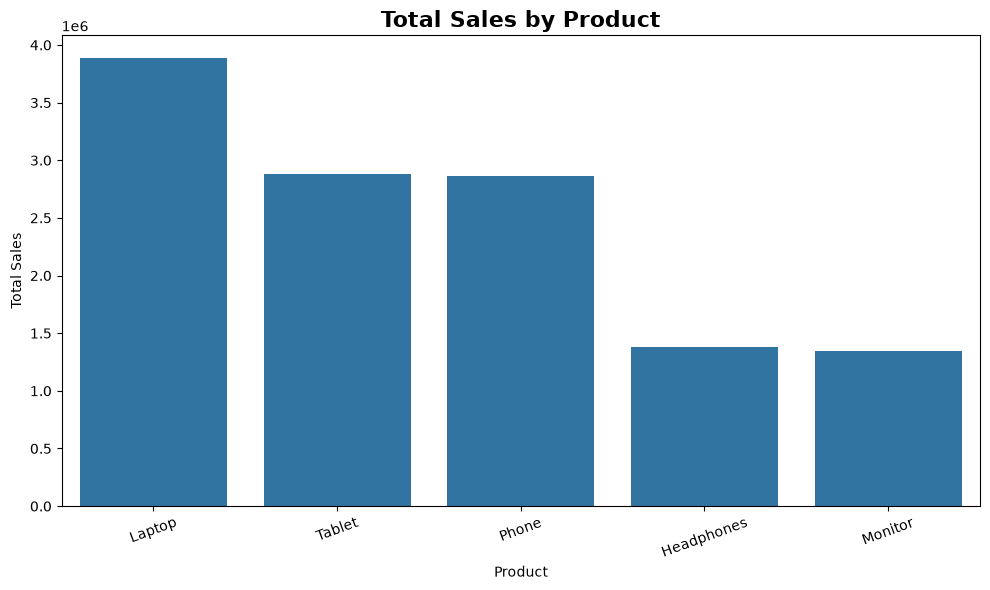

In [12]:
plt.figure(figsize=(10, 6))

product_sales = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=product_sales.index,
    y=product_sales.values
)

plt.title(
    "Total Sales by Product",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Interpretation

The product sales chart compares the total revenue generated by each product. It helps identify the strongest-performing products and highlights differences in overall product contribution to sales.

## 📈 Sales Trend Over Time

A time-series visualization helps identify changes in sales performance across the observation period.

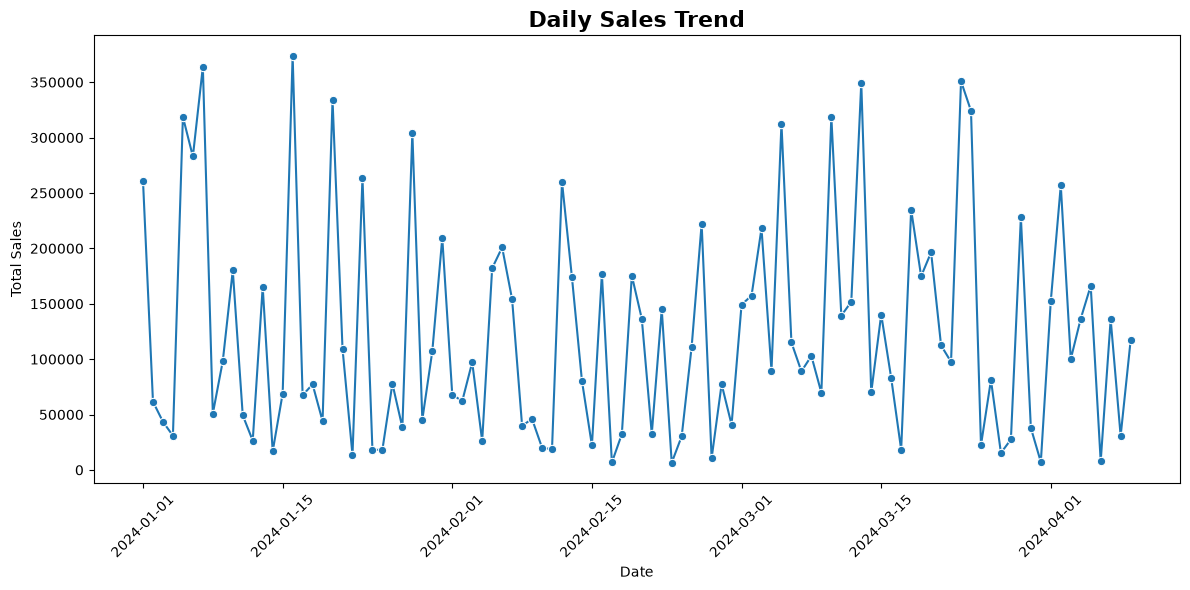

In [13]:
daily_sales = (
    df.groupby("Date")["Total_Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=daily_sales,
    x="Date",
    y="Total_Sales",
    marker="o"
)

plt.title(
    "Daily Sales Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The sales trend shows how total sales changed over time. Peaks indicate stronger sales days, while lower points represent comparatively weaker sales periods.

## 📦 Price Distribution by Product

A box plot is useful for comparing the distribution, median, spread, and potential outliers of product prices.

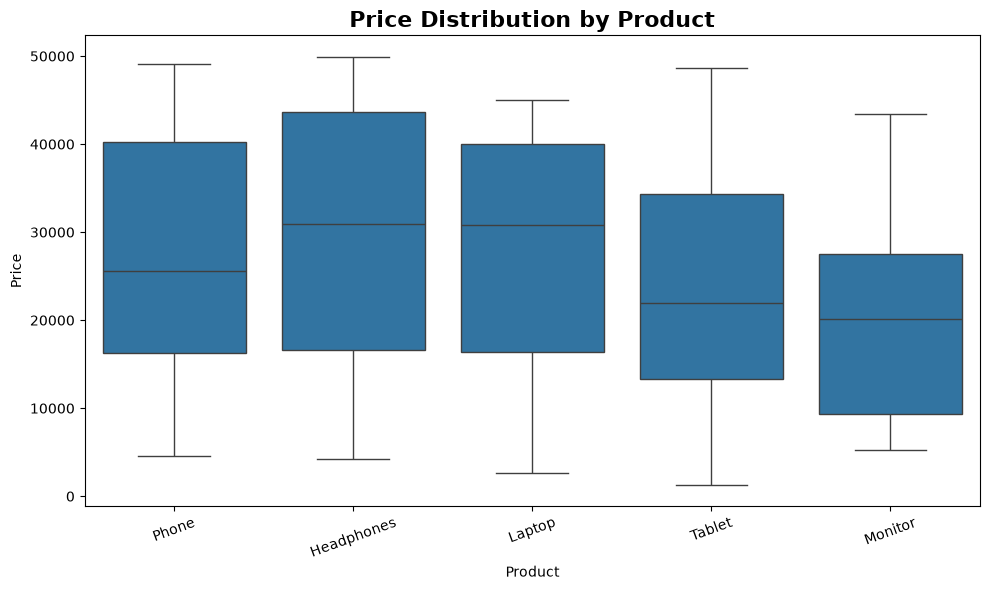

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Product",
    y="Price"
)

plt.title(
    "Price Distribution by Product",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product")
plt.ylabel("Price")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Interpretation

The box plot compares price distributions across products. The median represents the typical price, while the spread of each box shows how much prices vary. Points outside the normal range may indicate potential price outliers.

## 🎻 Sales Distribution by Region

A violin plot combines information about distribution and density, allowing regional sales patterns to be compared.

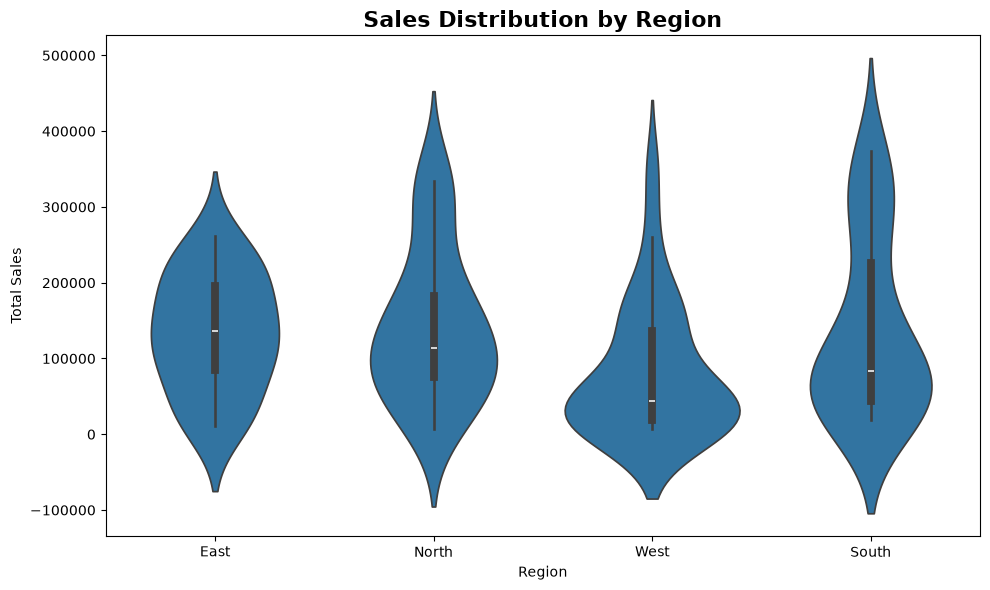

In [15]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Region",
    y="Total_Sales"
)

plt.title(
    "Sales Distribution by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Interpretation

The violin plot shows the distribution of sales within each region. Wider sections indicate areas where more observations are concentrated, helping identify differences in regional sales behavior.

## 🔥 Correlation Heatmap

The correlation heatmap examines relationships between the numerical variables in the dataset.

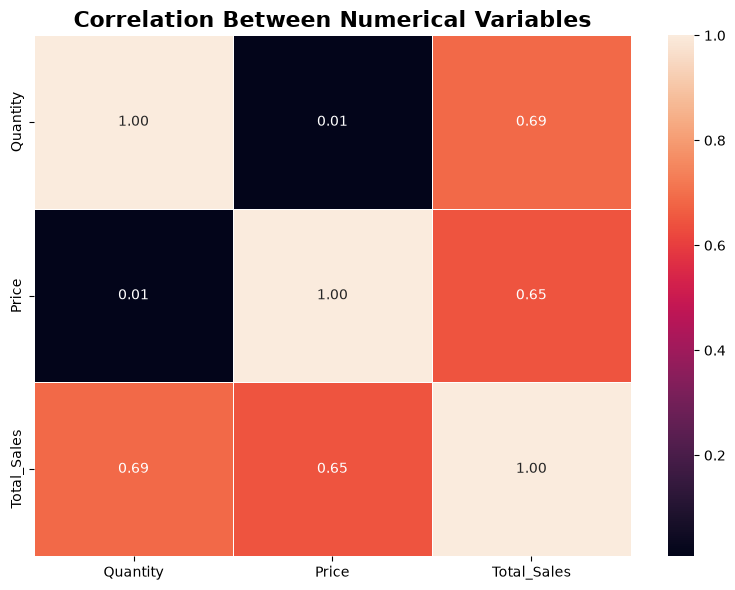

In [16]:
numeric_columns = [
    "Quantity",
    "Price",
    "Total_Sales"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Between Numerical Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interpretation

The heatmap displays correlation coefficients between quantity, price, and total sales.

A value close to **+1** indicates a strong positive relationship, a value close to **-1** indicates a strong negative relationship, and a value close to **0** indicates a weak linear relationship.

## 🌎 Regional Sales Performance

Regional analysis helps identify which geographical segments contribute most to total sales.

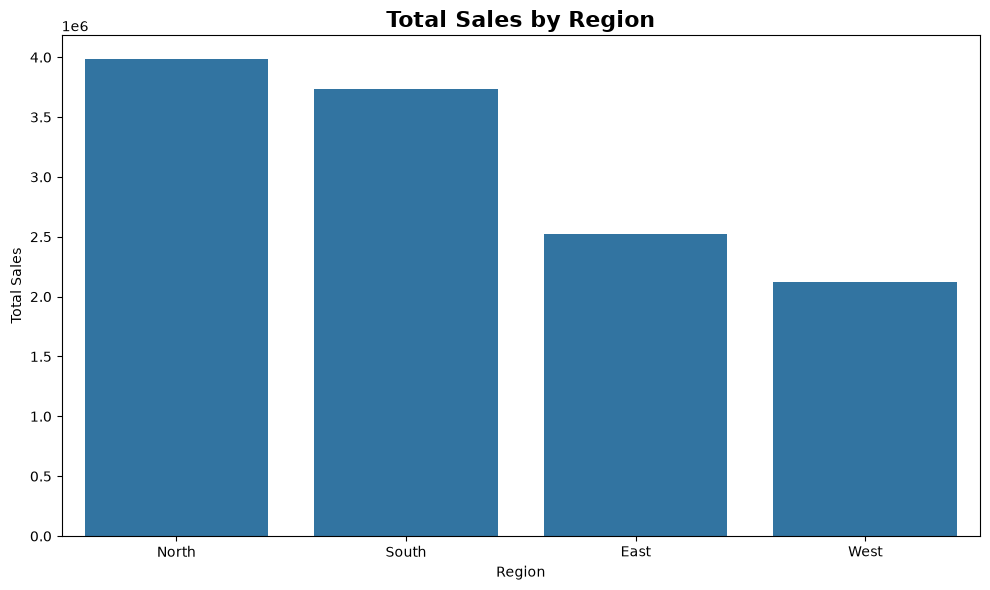

In [17]:
region_sales = (
    df.groupby("Region")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title(
    "Total Sales by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Interpretation

The regional sales comparison identifies the strongest and weakest geographical segments based on total sales. This can help businesses prioritize high-performing regions and investigate opportunities in lower-performing regions.

## 👥 Customer Segmentation

Customer-level analysis helps understand purchasing behavior and identify customers contributing significant sales value.

In [18]:
customer_summary = (
    df.groupby("Customer_ID")
    .agg(
        Total_Sales=("Total_Sales", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Transactions=("Customer_ID", "count")
    )
    .sort_values(
        "Total_Sales",
        ascending=False
    )
)

customer_summary.head(10)

,Total_Sales,Total_Quantity,Number_of_Transactions
Customer_ID,,,
CUST016,373932,9,1
CUST007,363870,9,1
CUST083,350888,8,1
CUST073,349510,7,1
CUST020,333992,8,1
CUST084,324144,8,1
CUST070,318762,9,1
CUST005,318680,8,1
CUST065,312564,7,1


# Customer sales chart

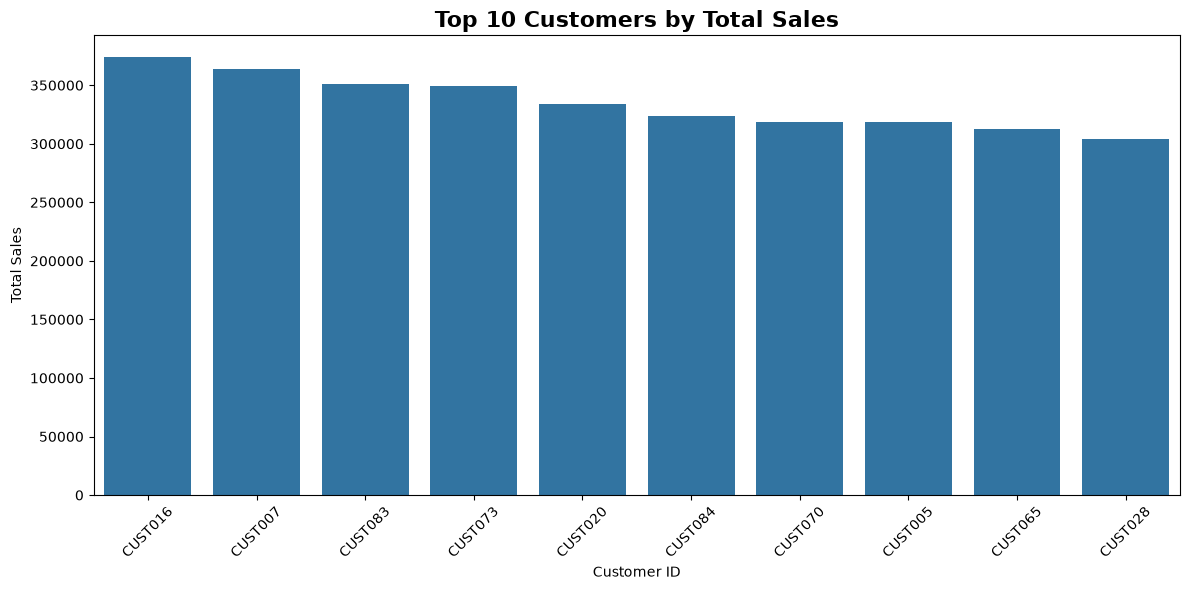

In [19]:
top_customers = customer_summary.head(10).reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_customers,
    x="Customer_ID",
    y="Total_Sales"
)

plt.title(
    "Top 10 Customers by Total Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer ID")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The customer analysis ranks customers according to their total sales contribution. Identifying high-value customers can support customer retention, targeted marketing, and personalized sales strategies.

## 💰 Key Performance Indicators

Key performance indicators provide a concise summary of the overall sales performance.

In [21]:
total_sales = df["Total_Sales"].sum()
total_quantity = df["Quantity"].sum()
average_sale = df["Total_Sales"].mean()
unique_customers = df["Customer_ID"].nunique()

print(f"Total Sales: ₹{total_sales:,.0f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Sale: ₹{average_sale:,.0f}")
print(f"Unique Customers: {unique_customers:,}")

Total Sales: ₹12,365,048
Total Quantity Sold: 478
Average Sale: ₹123,650
Unique Customers: 100


## 📊 2×2 Sales Visualization Dashboard

This dashboard combines four important views into a single figure:

1. Sales by Product
2. Sales by Region
3. Price Distribution
4. Correlation Between Numerical Variables

Combining multiple visualizations makes it easier to compare different aspects of sales performance at the same time.

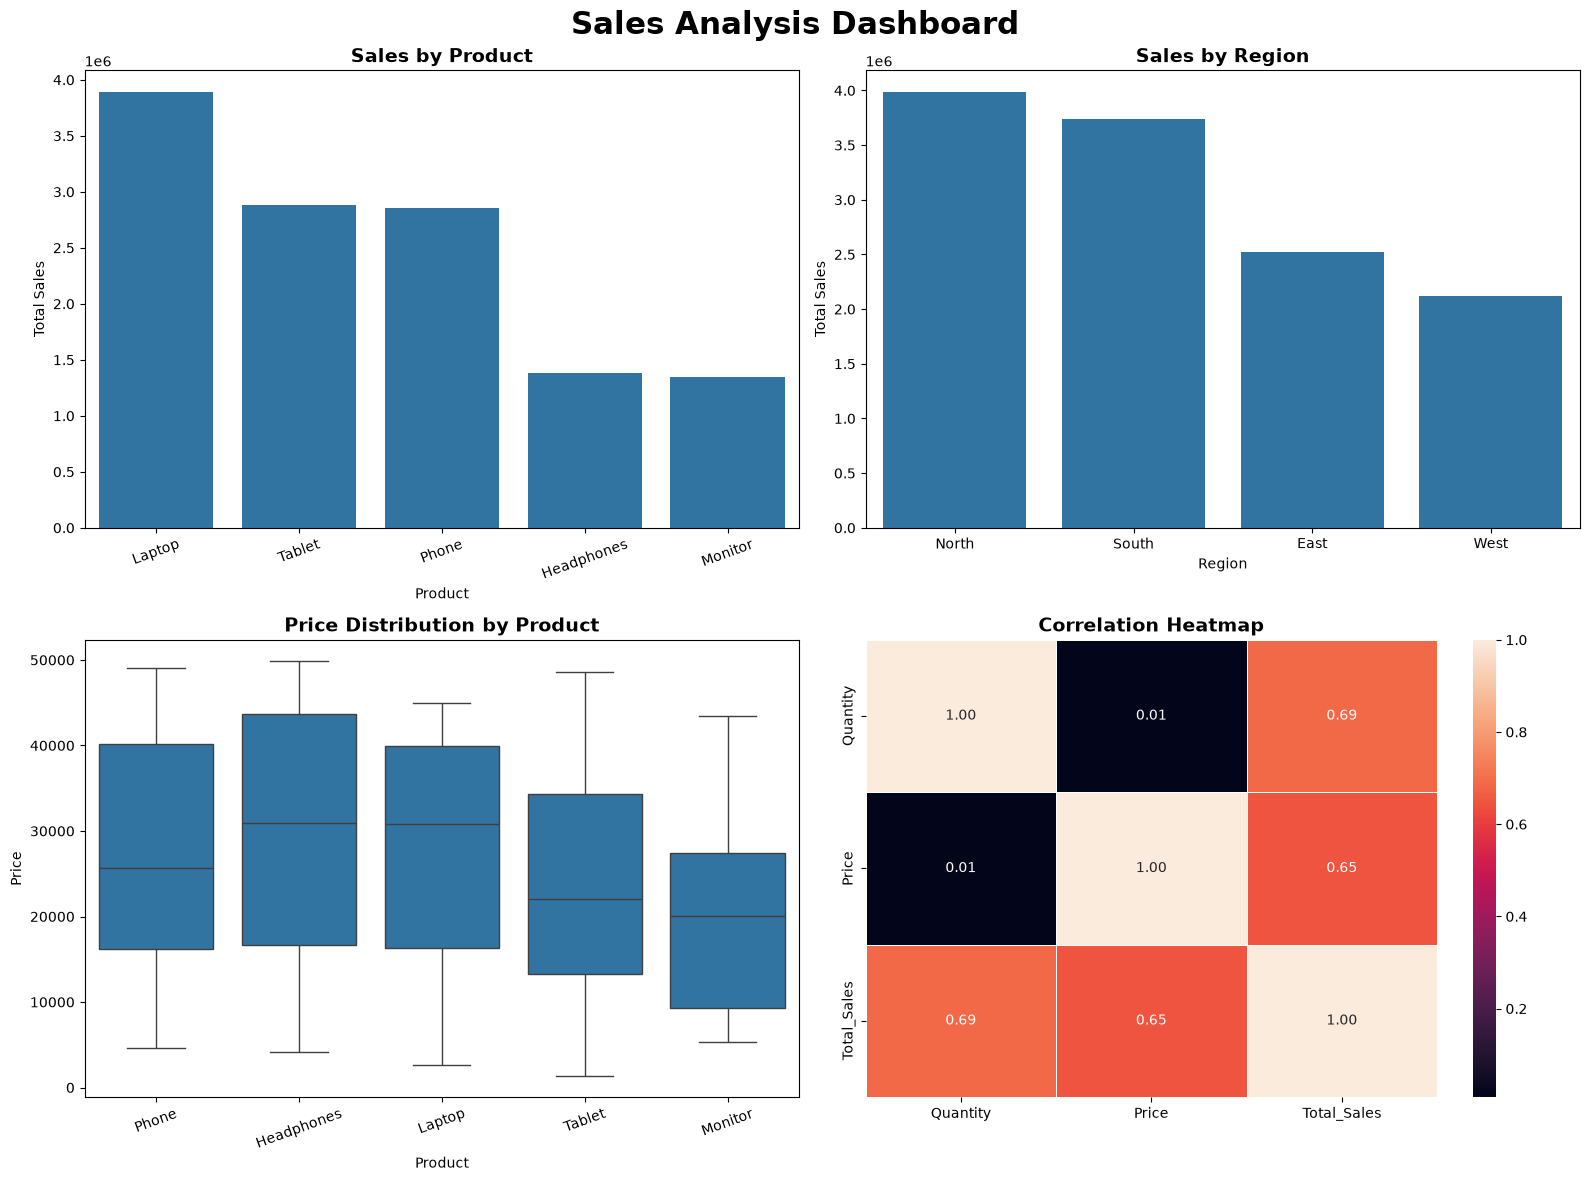

In [22]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

# ------------------------------------------------------------
# 1. Sales by Product
# ------------------------------------------------------------

product_sales = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=product_sales.index,
    y=product_sales.values,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Sales by Product",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Product")
axes[0, 0].set_ylabel("Total Sales")
axes[0, 0].tick_params(
    axis="x",
    rotation=20
)


# ------------------------------------------------------------
# 2. Sales by Region
# ------------------------------------------------------------

region_sales = (
    df.groupby("Region")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Sales by Region",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Total Sales")


# ------------------------------------------------------------
# 3. Price Distribution
# ------------------------------------------------------------

sns.boxplot(
    data=df,
    x="Product",
    y="Price",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Price Distribution by Product",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Product")
axes[1, 0].set_ylabel("Price")

axes[1, 0].tick_params(
    axis="x",
    rotation=20
)


# ------------------------------------------------------------
# 4. Correlation Heatmap
# ------------------------------------------------------------

numeric_data = df[
    [
        "Quantity",
        "Price",
        "Total_Sales"
    ]
]

correlation_matrix = numeric_data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Correlation Heatmap",
    fontsize=14,
    fontweight="bold"
)


# ------------------------------------------------------------
# Dashboard Formatting
# ------------------------------------------------------------

fig.suptitle(
    "Sales Analysis Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Dashboard Interpretation

The 2×2 dashboard provides a consolidated view of product performance, regional sales, pricing distribution, and relationships between numerical variables. It allows multiple dimensions of the dataset to be evaluated together and provides a foundation for the final interactive dashboard.

## 🖱️ Interactive Sales Dashboard

Plotly is used to transform the static analysis into an interactive dashboard. Users can explore sales performance through hover information, KPI indicators, interactive charts, and product filtering.

In [23]:
# Calculate dashboard KPIs

total_sales = df["Total_Sales"].sum()
total_quantity = df["Quantity"].sum()
average_sale = df["Total_Sales"].mean()
unique_customers = df["Customer_ID"].nunique()

print(f"Total Sales: ₹{total_sales:,.0f}")
print(f"Units Sold: {total_quantity:,}")
print(f"Average Sale: ₹{average_sale:,.0f}")
print(f"Unique Customers: {unique_customers:,}")

Total Sales: ₹12,365,048
Units Sold: 478
Average Sale: ₹123,650
Unique Customers: 100


In [24]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Aggregate data
product_sales = (
    df.groupby("Product", as_index=False)["Total_Sales"]
    .sum()
    .sort_values("Total_Sales", ascending=False)
)

region_sales = (
    df.groupby("Region", as_index=False)["Total_Sales"]
    .sum()
    .sort_values("Total_Sales", ascending=False)
)

daily_sales = (
    df.groupby("Date", as_index=False)["Total_Sales"]
    .sum()
)

# Create dashboard layout
fig = make_subplots(
    rows=4,
    cols=2,
    specs=[
        [
            {"type": "indicator"},
            {"type": "indicator"}
        ],
        [
            {"type": "indicator"},
            {"type": "indicator"}
        ],
        [
            {"type": "bar"},
            {"type": "pie"}
        ],
        [
            {"type": "scatter", "colspan": 2},
            None
        ]
    ],
    subplot_titles=[
        "Total Sales",
        "Units Sold",
        "Average Sale",
        "Unique Customers",
        "Sales by Product",
        "Sales by Region",
        "Daily Sales Trend"
    ],
    vertical_spacing=0.08
)

# ------------------------------------------------------------
# KPI 1 - Total Sales
# ------------------------------------------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_sales,
        number={
            "prefix": "₹",
            "valueformat": ",.0f"
        },
        title={
            "text": "Total Sales"
        }
    ),
    row=1,
    col=1
)

# ------------------------------------------------------------
# KPI 2 - Units Sold
# ------------------------------------------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_quantity,
        number={
            "valueformat": ",.0f"
        },
        title={
            "text": "Units Sold"
        }
    ),
    row=1,
    col=2
)

# ------------------------------------------------------------
# KPI 3 - Average Sale
# ------------------------------------------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=average_sale,
        number={
            "prefix": "₹",
            "valueformat": ",.0f"
        },
        title={
            "text": "Average Sale"
        }
    ),
    row=2,
    col=1
)

# ------------------------------------------------------------
# KPI 4 - Unique Customers
# ------------------------------------------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=unique_customers,
        number={
            "valueformat": ",.0f"
        },
        title={
            "text": "Unique Customers"
        }
    ),
    row=2,
    col=2
)

# ------------------------------------------------------------
# Product Sales
# ------------------------------------------------------------

fig.add_trace(
    go.Bar(
        x=product_sales["Product"],
        y=product_sales["Total_Sales"],
        name="Product Sales",
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Total Sales: ₹%{y:,.0f}"
            "<extra></extra>"
        )
    ),
    row=3,
    col=1
)

# ------------------------------------------------------------
# Regional Sales
# ------------------------------------------------------------

fig.add_trace(
    go.Pie(
        labels=region_sales["Region"],
        values=region_sales["Total_Sales"],
        hole=0.4,
        hovertemplate=(
            "<b>%{label}</b><br>"
            "Sales: ₹%{value:,.0f}<br>"
            "Share: %{percent}"
            "<extra></extra>"
        )
    ),
    row=3,
    col=2
)

# ------------------------------------------------------------
# Daily Sales Trend
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=daily_sales["Date"],
        y=daily_sales["Total_Sales"],
        mode="lines+markers",
        name="Daily Sales",
        hovertemplate=(
            "<b>%{x|%Y-%m-%d}</b><br>"
            "Sales: ₹%{y:,.0f}"
            "<extra></extra>"
        )
    ),
    row=4,
    col=1
)

# ------------------------------------------------------------
# Dashboard Layout
# ------------------------------------------------------------

fig.update_layout(
    title={
        "text": "Interactive Sales Dashboard",
        "x": 0.5,
        "xanchor": "center",
        "font": {
            "size": 26
        }
    },
    height=1200,
    width=1400,
    template="plotly_white",
    showlegend=False,
    margin={
        "l": 60,
        "r": 60,
        "t": 100,
        "b": 50
    }
)

fig.update_xaxes(
    title_text="Product",
    row=3,
    col=1
)

fig.update_yaxes(
    title_text="Total Sales",
    row=3,
    col=1
)

fig.update_xaxes(
    title_text="Date",
    row=4,
    col=1
)

fig.update_yaxes(
    title_text="Total Sales",
    row=4,
    col=1
)

fig.show()

In [25]:
# Create product filter options

product_options = ["All Products"] + sorted(
    df["Product"].unique().tolist()
)

buttons = []

# ------------------------------------------------------------
# All Products
# ------------------------------------------------------------

buttons.append(
    dict(
        label="All Products",
        method="update",
        args=[
            {
                "visible": [True] * len(fig.data)
            }
        ]
    )
)

# ------------------------------------------------------------
# Individual Products
# ------------------------------------------------------------

for product in sorted(df["Product"].unique()):

    buttons.append(
        dict(
            label=product,
            method="update",
            args=[
                {
                    "visible": [
                        True,
                        True,
                        True,
                        True,
                        product_sales["Product"].eq(product).any(),
                        True,
                        True
                    ]
                }
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.02,
            y=1.08,
            xanchor="left",
            yanchor="top",
            bgcolor="white",
            bordercolor="gray",
            borderwidth=1
        )
    ]
)

fig.show()

## 🎬 Animated Sales Visualization

An animated visualization is used to show how sales performance changes over time. The animation allows the viewer to move through the sales period and observe changes in product-level performance.

# monthly/product animation data

In [27]:
# Prepare data for animation

animation_data = (
    df.assign(
        Month=df["Date"].dt.strftime("%Y-%m")
    )
    .groupby(
        ["Month", "Product"],
        as_index=False
    )["Total_Sales"]
    .sum()
)

animation_data.head()

,Month,Product,Total_Sales
0,2024-01,Headphones,241498
1,2024-01,Laptop,1981281
2,2024-01,Monitor,67662
3,2024-01,Phone,937670
4,2024-01,Tablet,892413


# the animated chart

In [28]:
animated_fig = px.bar(
    animation_data,
    x="Product",
    y="Total_Sales",
    color="Product",
    animation_frame="Month",
    title="Animated Monthly Sales by Product",
    labels={
        "Total_Sales": "Total Sales",
        "Product": "Product"
    }
)

animated_fig.update_layout(
    template="plotly_white",
    xaxis_title="Product",
    yaxis_title="Total Sales"
)

animated_fig.show()

# Interactive Customer Analysis

In [29]:
customer_region_sales = (
    df.groupby(
        ["Region", "Product"],
        as_index=False
    )["Total_Sales"]
    .sum()
)

customer_region_sales.head()

,Region,Product,Total_Sales
0,East,Headphones,288361
1,East,Laptop,221946
2,East,Monitor,642870
3,East,Phone,506828
4,East,Tablet,859634


In [30]:
customer_fig = px.scatter(
    df,
    x="Quantity",
    y="Total_Sales",
    size="Price",
    color="Region",
    hover_data=[
        "Customer_ID",
        "Product",
        "Price"
    ],
    title="Customer Sales Behavior",
    labels={
        "Quantity": "Quantity Purchased",
        "Total_Sales": "Total Sales"
    }
)

customer_fig.update_layout(
    template="plotly_white"
)

customer_fig.show()

## 💡 Business Insights

### Product Performance
Product-level sales analysis helps identify which products contribute the greatest share of revenue.

### Regional Performance
Regional analysis highlights differences in sales contribution across geographical segments.

### Customer Segmentation
Customer-level analysis identifies high-value customers and provides insight into purchasing behavior.

### Price Distribution
Box and violin plots reveal differences in pricing and sales distributions and help identify unusual observations.

### Sales Trends
The time-series analysis provides visibility into changes in sales performance throughout the observation period.

### Correlation Analysis
The correlation heatmap helps identify relationships between quantity, price, and total sales.

### Interactive Exploration
Plotly visualizations allow users to explore the data through hover information, filtering, and animation rather than relying only on static charts.